# Brecha salarial de género en México

Proyecto final: Análisis de la brecha salarial de género y su relación con la participación laboral, usando datos de la OCDE y el Banco Mundial.

## 1. Planteamiento del problema

A pesar de los avances legales en materia de igualdad, en México sigue existiendo una diferencia entre lo que ganan hombres y mujeres. Quiero ver qué tan grande es esa diferencia, cómo ha cambiado en los últimos 20 años, y si tiene relación con cuántas mujeres participan en el mercado laboral.

**Por qué elegí este tema:** me parece un problema medible y con datos oficiales disponibles, a diferencia de otros temas de género donde la información es más escasa o menos comparable entre países.

**Objetivos:**
- Descargar la serie histórica de brecha salarial en México desde la OCDE.
- Compararla contra la participación laboral por sexo (Banco Mundial).
- Ver si ambas cosas se mueven juntas o son independientes.

**Hipótesis:**
- H1: la brecha salarial no ha bajado de forma sostenida en los últimos 20 años.
- H2: la brecha de participación laboral entre hombres y mujeres se mantiene sin importar lo que pase con el salario.

## 2. Preguntas que quiero responder

1. ¿Cómo ha cambiado la brecha salarial en México desde 2000?
2. ¿Cuál fue el año con más brecha y cuál con menos?
3. ¿Qué tan distinta es la participación laboral de hombres vs mujeres?
4. ¿La brecha salarial y la brecha de participación se comportan parecido?
5. ¿Qué tan completa es la información que tengo (faltan años)?



## 3. De dónde vienen los datos

Usé dos fuentes:

- **OCDE** (`sdmx.oecd.org`): Trae la brecha salarial de género calculada como mediana, que es el indicador que normalmente se reporta y compara entre países.
- **Banco Mundial** (`api.worldbank.org`): Participación laboral por sexo, para tener contexto de cuántas mujeres realmente trabajan, no solo cuánto ganan las que ya trabajan.

Elegí estas dos porque son organismos internacionales con metodología estandarizada, así que los datos son comparables entre países y se actualizan periódicamente. No necesité hacer scraping, ambas exponen API pública.

No hay ningún tema de privacidad aquí, son datos agregados por país y año, no de personas individuales.

Para organizar la consulta uso un diccionario con los indicadores del Banco Mundial y una tupla con el país (para no arriesgarme a modificarlo por accidente en el código).


In [1]:
# indicadores que voy a consultar en el Banco Mundial
INDICADORES_WORLD_BANK = {
    'SL.TLF.CACT.FE.ZS': 'Participación laboral femenina (%)',
    'SL.TLF.CACT.MA.ZS': 'Participación laboral masculina (%)',
}

PAIS_OBJETIVO = ('MEX', 'Mexico')  # tupla porque no debería cambiar durante la ejecución

for codigo, descripcion in INDICADORES_WORLD_BANK.items():
    print(codigo, '->', descripcion)

SL.TLF.CACT.FE.ZS -> Participación laboral femenina (%)
SL.TLF.CACT.MA.ZS -> Participación laboral masculina (%)


In [2]:
!pip install requests pandas matplotlib numpy -q

import requests
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

## 4. Consultando la API de la OCDE

Dataset: `Gender wage gap` (`https://data-explorer.oecd.org/s/499`).

El primer intento de filtrar directo por país en la URL me dio error 404 varias veces porque el número de versión del dataset cambia y el orden de las dimensiones no es obvio. Terminé resolviéndolo pidiendo el dataset completo (todos los países) y filtrando después con pandas, que es más lento pero no depende de adivinar la estructura exacta de la consulta.


In [3]:
def consultar_oecd_gender_wage_gap(pais_codigo='MEX', anio_inicio=2000):
    """
    Trae la brecha salarial de género de la OCDE para un país.

    Pide todo el dataset (no se puede filtrar país directo en la URL sin
    arriesgarse a un 404 por versión/dimensiones), filtra por REF_AREA y
    se queda con la serie "Median", que es el indicador oficial que reporta
    la OCDE (también existen Mean, Decile 1 y Decile 9, pero no los uso aquí).
    """
    url = 'https://sdmx.oecd.org/public/rest/data/OECD.ELS.SAE,DSD_EARNINGS@GENDER_WAGE_GAP,/all'
    parametros = {
        'startPeriod': anio_inicio,
        'dimensionAtObservation': 'AllDimensions',
        'format': 'csvfilewithlabels'
    }

    try:
        respuesta = requests.get(url, params=parametros, timeout=30)
        respuesta.raise_for_status()

        todos_los_paises = pd.read_csv(io.StringIO(respuesta.text))
        if todos_los_paises.empty:
            print('la OCDE respondió vacío')
            return None

        print(f'{len(todos_los_paises)} filas descargadas (todos los países)')

        solo_pais = todos_los_paises[todos_los_paises['REF_AREA'] == pais_codigo]
        if solo_pais.empty:
            print(f'no hay filas para {pais_codigo}')
            return None

        solo_mediana = solo_pais[solo_pais['Aggregation operation'] == 'Median']
        if solo_mediana.empty:
            print('no se encontró la serie Median para este país')
            return None

        tabla = solo_mediana[['TIME_PERIOD', 'OBS_VALUE']].rename(
            columns={'TIME_PERIOD': 'anio', 'OBS_VALUE': 'brecha_salarial_pct'}
        ).sort_values('anio').reset_index(drop=True)

        print(f'{len(tabla)} filas para {pais_codigo}')
        return tabla

    except requests.exceptions.HTTPError as e:
        print('error HTTP en la consulta a la OCDE:', e)
        return None
    except requests.exceptions.RequestException as e:
        print('error de conexión con la OCDE:', e)
        return None
    except pd.errors.ParserError as e:
        print('la respuesta no vino en CSV válido:', e)
        return None


df_oecd = consultar_oecd_gender_wage_gap(pais_codigo=PAIS_OBJETIVO[0], anio_inicio=2000)
df_oecd

3132 filas descargadas (todos los países)
18 filas para MEX


,anio,brecha_salarial_pct
0,2005,16.666667
1,2006,18.604651
2,2007,12.500000
3,2008,22.222222
4,2009,16.666667
5,2010,11.627907
6,2011,10.000000
7,2012,13.555556
8,2013,15.433404
9,2014,18.300000


## 5. Participación laboral (Banco Mundial)

Aquí sí pude automatizar directo con un `for` sobre el diccionario de indicadores, sin el problema de dimensiones que tuvo la OCDE.


In [4]:
def consultar_world_bank(pais='MEX', indicador='SL.TLF.CACT.FE.ZS'):
    """Trae un indicador del Banco Mundial para un país. Devuelve [anio, valor]."""
    url = f'https://api.worldbank.org/v2/country/{pais}/indicator/{indicador}'
    parametros = {'format': 'json', 'per_page': 200}

    try:
        respuesta = requests.get(url, params=parametros, timeout=15)
        respuesta.raise_for_status()
        datos = respuesta.json()

        if len(datos) < 2 or not datos[1]:
            print(f'  sin datos para {indicador}')
            return None

        tabla = pd.DataFrame(datos[1])[['date', 'value']].rename(columns={'date': 'anio', 'value': 'valor'})
        tabla['anio'] = tabla['anio'].astype(int)
        tabla = tabla.dropna(subset=['valor']).sort_values('anio').reset_index(drop=True)
        return tabla

    except requests.exceptions.RequestException as e:
        print(f'  error de conexión ({indicador}):', e)
        return None


resultados_wb = {}
for codigo, descripcion in INDICADORES_WORLD_BANK.items():
    print('descargando:', descripcion)
    tabla = consultar_world_bank(pais=PAIS_OBJETIVO[0], indicador=codigo)
    if tabla is not None:
        resultados_wb[codigo] = tabla

df_wb_mujeres = resultados_wb.get('SL.TLF.CACT.FE.ZS')
df_wb_hombres = resultados_wb.get('SL.TLF.CACT.MA.ZS')

df_wb_mujeres.tail(10)

descargando: Participación laboral femenina (%)
descargando: Participación laboral masculina (%)


,anio,valor
26,2016,43.988
27,2017,43.627
28,2018,44.134
29,2019,45.573
30,2020,41.704
31,2021,44.615
32,2022,46.004
33,2023,47.317
34,2024,47.414
35,2025,47.450


Uno los dos indicadores del Banco Mundial en una sola tabla, por año.

In [5]:
df_participacion = df_wb_mujeres.merge(
    df_wb_hombres, on='anio', suffixes=('_mujeres', '_hombres')
).rename(columns={'valor_mujeres': 'participacion_mujeres', 'valor_hombres': 'participacion_hombres'})

df_participacion.tail(10)

,anio,participacion_mujeres,participacion_hombres
26,2016,43.988,78.273
27,2017,43.627,78.237
28,2018,44.134,78.165
29,2019,45.573,78.057
30,2020,41.704,72.492
31,2021,44.615,76.673
32,2022,46.004,77.314
33,2023,47.317,77.551
34,2024,47.414,77.215
35,2025,47.450,77.113


## 6. Explorando los datos antes de seguir

Antes de sacar conclusiones reviso tamaño, tipos de dato y si hay nulos o duplicados en ambas tablas.


In [6]:
print('--- brecha salarial (OCDE) ---')
print('filas:', df_oecd.shape[0], '| columnas:', df_oecd.shape[1])
df_oecd.info()
print()
df_oecd.describe()

--- brecha salarial (OCDE) ---
filas: 18 | columnas: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio                 18 non-null     int64  
 1   brecha_salarial_pct  18 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 420.0 bytes



,anio,brecha_salarial_pct
count,18.000000,18.000000
mean,2014.000000,15.260024
std,6.087596,3.050664
min,2005.000000,10.000000
25%,2009.250000,12.763889
50%,2013.500000,15.962826
75%,2017.750000,16.666667
max,2025.000000,22.222222


In [7]:
print('nulos por columna:')
print(df_oecd.isnull().sum())
print('duplicados:', df_oecd.duplicated().sum())

nulos por columna:
anio                   0
brecha_salarial_pct    0
dtype: int64
duplicados: 0


In [8]:
print('--- participación laboral (Banco Mundial) ---')
print('filas:', df_participacion.shape[0], '| columnas:', df_participacion.shape[1])
df_participacion.info()
print()
df_participacion.describe()

--- participación laboral (Banco Mundial) ---
filas: 36 | columnas: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   anio                   36 non-null     int64  
 1   participacion_mujeres  36 non-null     float64
 2   participacion_hombres  36 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 996.0 bytes



,anio,participacion_mujeres,participacion_hombres
count,36.000000,36.000000,36.000000
mean,2007.500000,41.364528,80.226972
std,10.535654,3.782199,2.727322
min,1990.000000,33.981000,72.492000
25%,1998.750000,38.473750,78.264000
50%,2007.500000,42.451000,80.258000
75%,2016.250000,44.024500,82.775750
max,2025.000000,47.450000,84.496000


In [9]:
print('nulos por columna:')
print(df_participacion.isnull().sum())
print('duplicados:', df_participacion.duplicated().sum())

nulos por columna:
anio                     0
participacion_mujeres    0
participacion_hombres    0
dtype: int64
duplicados: 0


Un vistazo rápido antes de entrar más a fondo:

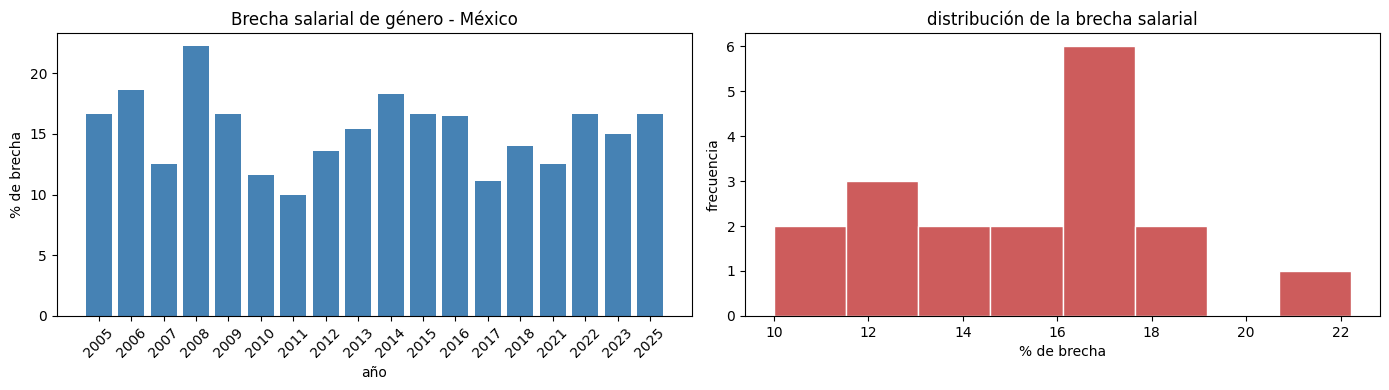

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(df_oecd['anio'].astype(str), df_oecd['brecha_salarial_pct'], color='steelblue')
axes[0].set_title('Brecha salarial de género - México')
axes[0].set_xlabel('año')
axes[0].set_ylabel('% de brecha')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df_oecd['brecha_salarial_pct'], bins=8, color='indianred', edgecolor='white')
axes[1].set_title('distribución de la brecha salarial')
axes[1].set_xlabel('% de brecha')
axes[1].set_ylabel('frecuencia')

plt.tight_layout()
plt.show()

## 7. Revisando huecos en la serie de tiempo

La OCDE no publica el dato todos los años, así que reviso cuáles faltan en vez de asumir que la serie es continua. No voy a rellenar esos huecos con un promedio ni nada parecido, porque inventar una brecha salarial para un año sin encuesta sería mentir con los datos mejor dejar el hueco documentado.


In [11]:
anio_min, anio_max = df_oecd['anio'].min(), df_oecd['anio'].max()
anios_esperados = set(range(anio_min, anio_max + 1))
anios_con_dato = set(df_oecd['anio'])
faltantes = sorted(anios_esperados - anios_con_dato)

print(f'rango: {anio_min}-{anio_max}')
print(f'años con dato: {len(anios_con_dato)} de {len(anios_esperados)}')
print('años sin dato:', faltantes if faltantes else 'ninguno')

rango: 2005-2025
años con dato: 18 de 21
años sin dato: [2019, 2020, 2024]


## 8. Selección de datos con .loc y .iloc

In [12]:
# .loc: selección por condición
brecha_reciente = df_oecd.loc[df_oecd['anio'] >= 2020, ['anio', 'brecha_salarial_pct']]
brecha_reciente

,anio,brecha_salarial_pct
14,2021,12.500000
15,2022,16.666667
16,2023,15.000000
17,2025,16.666667


In [13]:
# .iloc: selección por posición
df_oecd.iloc[0:3]

,anio,brecha_salarial_pct
0,2005,16.666667
1,2006,18.604651
2,2007,12.500000


## 9. Columnas nuevas y estadísticas

Agrego una columna que clasifica cada año como brecha alta/baja respecto a la mediana histórica, y un z-score para ver qué tan lejos está cada año del promedio.


In [14]:
mediana_hist = df_oecd['brecha_salarial_pct'].median()
media_hist = df_oecd['brecha_salarial_pct'].mean()
desv_hist = df_oecd['brecha_salarial_pct'].std()

df_oecd['nivel_brecha'] = df_oecd['brecha_salarial_pct'].apply(
    lambda x: 'alta' if x > mediana_hist else 'baja'
)
df_oecd['z_score'] = np.round((df_oecd['brecha_salarial_pct'] - media_hist) / desv_hist, 2)

df_oecd

,anio,brecha_salarial_pct,nivel_brecha,z_score
0,2005,16.666667,alta,0.46
1,2006,18.604651,alta,1.10
2,2007,12.500000,baja,-0.90
3,2008,22.222222,alta,2.28
4,2009,16.666667,alta,0.46
5,2010,11.627907,baja,-1.19
6,2011,10.000000,baja,-1.72
7,2012,13.555556,baja,-0.56
8,2013,15.433404,baja,0.06
9,2014,18.300000,alta,1.00


In [15]:
print(f'promedio:  {df_oecd["brecha_salarial_pct"].mean():.2f}%')
print(f'mediana:   {df_oecd["brecha_salarial_pct"].median():.2f}%')
print(f'mínimo:    {df_oecd["brecha_salarial_pct"].min():.2f}% (año {df_oecd.loc[df_oecd["brecha_salarial_pct"].idxmin(), "anio"]})')
print(f'máximo:    {df_oecd["brecha_salarial_pct"].max():.2f}% (año {df_oecd.loc[df_oecd["brecha_salarial_pct"].idxmax(), "anio"]})')
print(f'desv est:  {df_oecd["brecha_salarial_pct"].std():.2f}')

promedio:  15.26%
mediana:   15.96%
mínimo:    10.00% (año 2011)
máximo:    22.22% (año 2008)
desv est:  3.05


In [16]:
# checar que no haya quedado ningún NaN antes de dar por cerrada la limpieza
print('nulos en df_oecd:', df_oecd.isnull().values.any())
print('nulos en df_participacion:', df_participacion.isnull().values.any())

nulos en df_oecd: False
nulos en df_participacion: False


## 10. Brecha salarial vs. participación laboral

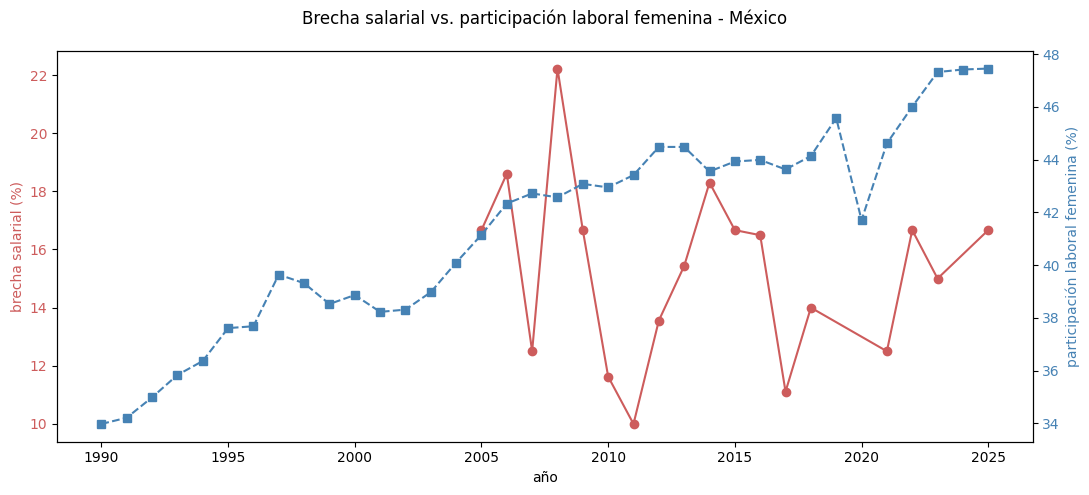

In [17]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(df_oecd['anio'], df_oecd['brecha_salarial_pct'], color='indianred', marker='o', label='brecha salarial (%)')
ax1.set_xlabel('año')
ax1.set_ylabel('brecha salarial (%)', color='indianred')
ax1.tick_params(axis='y', labelcolor='indianred')

ax2 = ax1.twinx()
ax2.plot(df_participacion['anio'], df_participacion['participacion_mujeres'],
         color='steelblue', marker='s', linestyle='--', label='participación laboral mujeres (%)')
ax2.set_ylabel('participación laboral femenina (%)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

fig.suptitle('Brecha salarial vs. participación laboral femenina - México')
fig.tight_layout()
plt.show()

## 11. Guardar resultados

In [18]:
# Para obtener en la sesión el archivo.
df_oecd.to_csv('oecd_brecha_salarial_mexico.csv', index=False)
df_participacion.to_csv('worldbank_participacion_laboral_mexico.csv', index=False)
print('listo, dos archivos guardados')


listo, dos archivos guardados


## 12. Conclusiones

La brecha salarial de género (mediana) en México se movió entre 10% y 22% aproximadamente entre 2005 y 2025, sin que se vea una tendencia clara de reducción esto va en línea con H1.

Faltan varios años en la serie (2019, 2020, 2024, entre otros), lo que limita qué tan fino se puede analizar la tendencia año con año.

Falta cruzar esto con participación laboral de forma más rigurosa (por ahora solo está el gráfico comparativo, no un análisis estadístico de correlación).

**Siguientes pasos:**
- Correr una regresión simple para ver si la tendencia es estadísticamente significativa o si el movimiento es solo ruido.
- Agregar más países de la OCDE para tener un punto de comparación, ahora mismo solo hay México.
- Revisar si vale la pena usar las series de Decile 1 / Decile 9 que se dejaron fuera, para ver si la brecha es distinta en la parte baja vs alta de la distribución salarial.
- Si el proyecto sigue creciendo, pasar los datos a una base (Mongo o MySQL) en vez de CSV sueltos.
